In [1]:
!pip install pandas numpy scikit-learn beautifulsoup4 requests joblib


In [2]:
import pandas as pd
import numpy as np

import requests
from bs4 import BeautifulSoup

import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
data = {
    "product_name": [
        "Terracotta Vase",
        "Clay Flower Pot",
        "Ceramic Vase",
        "Traditional Diya Set",
        "Wooden Wall Decor",
        "Wooden Box",
        "Cotton Handbag",
        "Jute Bag",
        "Handmade Necklace",
        "Beaded Necklace",
        "Traditional Painting",
        "Handmade Painting",
        "Bamboo Basket",
        "Handwoven Basket",
        "Embroidered Cushion",
        "Handmade Shawl",
        "Clay Sculpture",
        "Wooden Sculpture",
        "Terracotta Pot",
        "Ceramic Bowl"
    ],

    "category": [
        "Pottery",
        "Pottery",
        "Pottery",
        "Pottery",
        "Home Decor",
        "Handicraft",
        "Bag",
        "Bag",
        "Jewellery",
        "Jewellery",
        "Painting",
        "Painting",
        "Handicraft",
        "Handicraft",
        "Textile",
        "Textile",
        "Handicraft",
        "Handicraft",
        "Pottery",
        "Pottery"
    ],

    "material": [
        "Terracotta",
        "Clay",
        "Ceramic",
        "Clay",
        "Wood",
        "Wood",
        "Cotton",
        "Jute",
        "Metal",
        "Beads",
        "Canvas",
        "Canvas",
        "Bamboo",
        "Cane",
        "Cotton",
        "Wool",
        "Clay",
        "Wood",
        "Terracotta",
        "Ceramic"
    ],

    "size": [
        "Medium",
        "Small",
        "Large",
        "Small",
        "Medium",
        "Small",
        "Medium",
        "Medium",
        "Small",
        "Small",
        "Medium",
        "Large",
        "Medium",
        "Large",
        "Medium",
        "Large",
        "Medium",
        "Large",
        "Large",
        "Medium"
    ],

    "rating": [
        4.5, 4.2, 4.6, 4.4, 4.3,
        4.5, 4.1, 4.4, 4.6, 4.3,
        4.7, 4.8, 4.3, 4.5, 4.4,
        4.7, 4.5, 4.6, 4.3, 4.4
    ],

    "reviews": [
        120, 80, 150, 100, 90,
        110, 75, 140, 180, 95,
        200, 250, 130, 160, 100,
        190, 135, 145, 125, 105
    ],

    "price": [
        650, 350, 900, 300, 800,
        550, 600, 750, 500, 450,
        1200, 1800, 400, 700, 550,
        1500, 850, 1300, 750, 500
    ]
}

df = pd.DataFrame(data)

df.head()

,product_name,category,material,size,rating,reviews,price
0,Terracotta Vase,Pottery,Terracotta,Medium,4.5,120,650
1,Clay Flower Pot,Pottery,Clay,Small,4.2,80,350
2,Ceramic Vase,Pottery,Ceramic,Large,4.6,150,900
3,Traditional Diya Set,Pottery,Clay,Small,4.4,100,300
4,Wooden Wall Decor,Home Decor,Wood,Medium,4.3,90,800


In [4]:
print("Number of products:", len(df))

print("\nColumns:")
print(df.columns)

print("\nDataset:")
display(df)

Number of products: 20

Columns:
Index(['product_name', 'category', 'material', 'size', 'rating', 'reviews',
       'price'],
      dtype='object')

Dataset:


,product_name,category,material,size,rating,reviews,price
0,Terracotta Vase,Pottery,Terracotta,Medium,4.5,120,650
1,Clay Flower Pot,Pottery,Clay,Small,4.2,80,350
2,Ceramic Vase,Pottery,Ceramic,Large,4.6,150,900
3,Traditional Diya Set,Pottery,Clay,Small,4.4,100,300
4,Wooden Wall Decor,Home Decor,Wood,Medium,4.3,90,800
5,Wooden Box,Handicraft,Wood,Small,4.5,110,550
6,Cotton Handbag,Bag,Cotton,Medium,4.1,75,600
7,Jute Bag,Bag,Jute,Medium,4.4,140,750
8,Handmade Necklace,Jewellery,Metal,Small,4.6,180,500
9,Beaded Necklace,Jewellery,Beads,Small,4.3,95,450


In [5]:
X = df[
    [
        "category",
        "material",
        "size",
        "rating",
        "reviews"
    ]
]

y = df["price"]

In [6]:
categorical_features = [
    "category",
    "material",
    "size"
]

numerical_features = [
    "rating",
    "reviews"
]

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),

        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [8]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [9]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
pipeline.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
predictions = pipeline.predict(X_test)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 2))

MAE: 293.31
RMSE: 387.32
R2 Score: 0.31


In [13]:
new_product = pd.DataFrame([
    {
        "category": "Pottery",
        "material": "Terracotta",
        "size": "Medium",
        "rating": 4.5,
        "reviews": 100
    }
])

In [14]:
predicted_price = pipeline.predict(
    new_product
)[0]

print(
    "Estimated Price: ₹",
    round(predicted_price)
)

Estimated Price: ₹ 617


In [15]:
minimum_price = predicted_price * 0.90
maximum_price = predicted_price * 1.10

print(
    "Recommended Price Range: ₹",
    round(minimum_price),
    "- ₹",
    round(maximum_price)
)

Recommended Price Range: ₹ 556 - ₹ 679


In [16]:
joblib.dump(
    pipeline,
    "price_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


PHASE 2 — WEB SCRAPING

In [29]:
import requests
from bs4 import BeautifulSoup

url = "https://www.mystore.in/en/search/handcrafted%20pottery"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(
    url,
    headers=headers,
    timeout=10
)

print("Status Code:", response.status_code)

Status Code: 200


In [30]:
soup = BeautifulSoup(
    response.text,
    "html.parser"
)

print(soup.title)

None


In [66]:
new_products = pd.DataFrame({
    "product_name": [
        "Terracotta Vase",
        "Clay Flower Pot",
        "Ceramic Vase",
        "Traditional Diya Set",
        "Wooden Wall Decor"
    ],

    "category": [
        "Pottery",
        "Pottery",
        "Pottery",
        "Pottery",
        "Home Decor"
    ],

    "material": [
        "Terracotta",
        "Clay",
        "Ceramic",
        "Clay",
        "Wood"
    ],

    "size": [
        "Medium",
        "Small",
        "Large",
        "Small",
        "Medium"
    ],

    "rating": [
        4.5,
        4.2,
        4.6,
        4.4,
        4.3
    ],

    "reviews": [
        120,
        80,
        150,
        100,
        90
    ],

    "price": [
        650,
        350,
        900,
        300,
        800
    ]
})

print(new_products)

           product_name    category    material    size  rating  reviews  \
0       Terracotta Vase     Pottery  Terracotta  Medium     4.5      120   
1       Clay Flower Pot     Pottery        Clay   Small     4.2       80   
2          Ceramic Vase     Pottery     Ceramic   Large     4.6      150   
3  Traditional Diya Set     Pottery        Clay   Small     4.4      100   
4     Wooden Wall Decor  Home Decor        Wood  Medium     4.3       90   

   price  
0    650  
1    350  
2    900  
3    300  
4    800  


In [67]:
df = pd.concat([df, new_products], ignore_index=True)

print("Total products:", len(df))
print(df)

Total products: 25
            product_name    category    material    size  rating  reviews  \
0        Terracotta Vase     Pottery  Terracotta  Medium     4.5      120   
1        Clay Flower Pot     Pottery        Clay   Small     4.2       80   
2           Ceramic Vase     Pottery     Ceramic   Large     4.6      150   
3   Traditional Diya Set     Pottery        Clay   Small     4.4      100   
4      Wooden Wall Decor  Home Decor        Wood  Medium     4.3       90   
5             Wooden Box  Handicraft        Wood   Small     4.5      110   
6         Cotton Handbag         Bag      Cotton  Medium     4.1       75   
7               Jute Bag         Bag        Jute  Medium     4.4      140   
8      Handmade Necklace   Jewellery       Metal   Small     4.6      180   
9        Beaded Necklace   Jewellery       Beads   Small     4.3       95   
10  Traditional Painting    Painting      Canvas  Medium     4.7      200   
11     Handmade Painting    Painting      Canvas   Large 

In [77]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (25, 7)

Column Names:
Index(['product_name', 'category', 'material', 'size', 'rating', 'reviews',
       'price'],
      dtype='object')

Missing Values:
product_name    0
category        0
material        0
size            0
rating          0
reviews         0
price           0
dtype: int64

Duplicate Rows:
5


In [78]:
df = df.drop_duplicates()

df = df.dropna()

print("Dataset after cleaning:")
print(df)

print("\nNew Shape:", df.shape)

Dataset after cleaning:
            product_name    category    material    size  rating  reviews  \
0        Terracotta Vase     Pottery  Terracotta  Medium     4.5      120   
1        Clay Flower Pot     Pottery        Clay   Small     4.2       80   
2           Ceramic Vase     Pottery     Ceramic   Large     4.6      150   
3   Traditional Diya Set     Pottery        Clay   Small     4.4      100   
4      Wooden Wall Decor  Home Decor        Wood  Medium     4.3       90   
5             Wooden Box  Handicraft        Wood   Small     4.5      110   
6         Cotton Handbag         Bag      Cotton  Medium     4.1       75   
7               Jute Bag         Bag        Jute  Medium     4.4      140   
8      Handmade Necklace   Jewellery       Metal   Small     4.6      180   
9        Beaded Necklace   Jewellery       Beads   Small     4.3       95   
10  Traditional Painting    Painting      Canvas  Medium     4.7      200   
11     Handmade Painting    Painting      Canvas   L

In [79]:
import re

def clean_price(price):
    price = str(price)
    price = re.sub(r"[^\d.]", "", price)

    try:
        return float(price)
    except:
        return None

df["price"] = df["price"].apply(clean_price)

df = df.dropna(subset=["price"])

print(df[["product_name", "price"]])

            product_name   price
0        Terracotta Vase   650.0
1        Clay Flower Pot   350.0
2           Ceramic Vase   900.0
3   Traditional Diya Set   300.0
4      Wooden Wall Decor   800.0
5             Wooden Box   550.0
6         Cotton Handbag   600.0
7               Jute Bag   750.0
8      Handmade Necklace   500.0
9        Beaded Necklace   450.0
10  Traditional Painting  1200.0
11     Handmade Painting  1800.0
12         Bamboo Basket   400.0
13      Handwoven Basket   700.0
14   Embroidered Cushion   550.0
15        Handmade Shawl  1500.0
16        Clay Sculpture   850.0
17      Wooden Sculpture  1300.0
18        Terracotta Pot   750.0
19          Ceramic Bowl   500.0


In [80]:
print(df.dtypes)

product_name     object
category         object
material         object
size             object
rating          float64
reviews           int64
price           float64
dtype: object


In [81]:
print("Price Statistics:")
print(df["price"].describe())

Price Statistics:
count      20.000000
mean      770.000000
std       398.153633
min       300.000000
25%       500.000000
50%       675.000000
75%       862.500000
max      1800.000000
Name: price, dtype: float64


In [82]:
category_prices = df.groupby("category")["price"].mean()

print(category_prices)

category
Bag            675.0
Handicraft     760.0
Home Decor     800.0
Jewellery      475.0
Painting      1500.0
Pottery        575.0
Textile       1025.0
Name: price, dtype: float64


In [83]:
material_prices = df.groupby("material")["price"].mean()

print(material_prices)

material
Bamboo         400.000000
Beads          450.000000
Cane           700.000000
Canvas        1500.000000
Ceramic        700.000000
Clay           500.000000
Cotton         575.000000
Jute           750.000000
Metal          500.000000
Terracotta     700.000000
Wood           883.333333
Wool          1500.000000
Name: price, dtype: float64


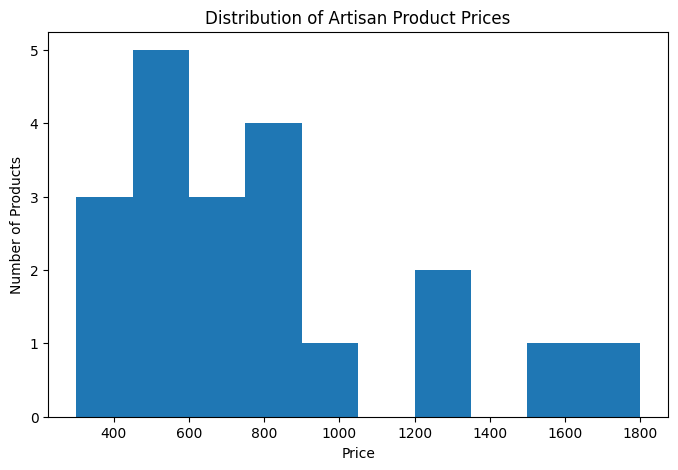

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=10)

plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.title("Distribution of Artisan Product Prices")

plt.show()

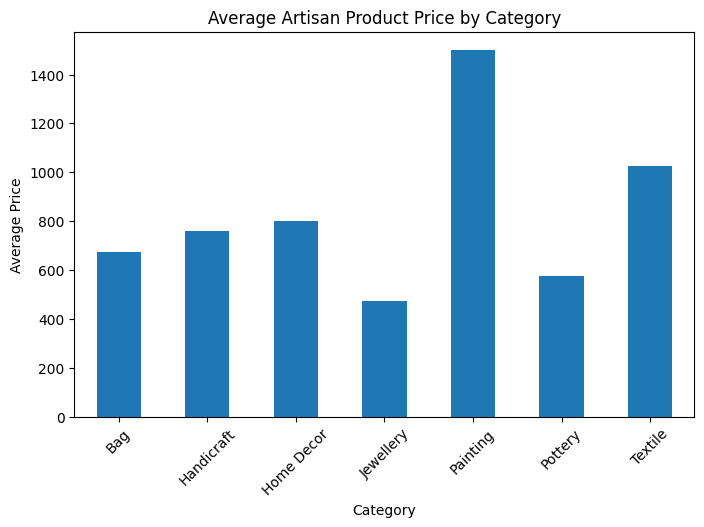

In [85]:
category_prices = df.groupby("category")["price"].mean()

plt.figure(figsize=(8,5))

category_prices.plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Average Price")
plt.title("Average Artisan Product Price by Category")

plt.xticks(rotation=45)

plt.show()

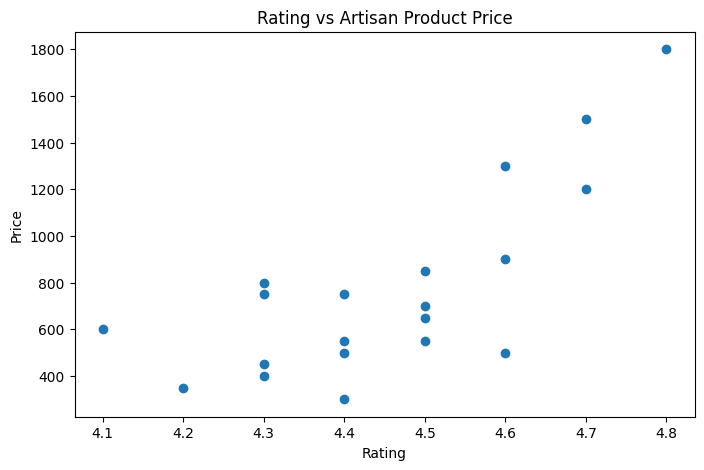

In [86]:
plt.figure(figsize=(8,5))

plt.scatter(df["rating"], df["price"])

plt.xlabel("Rating")
plt.ylabel("Price")
plt.title("Rating vs Artisan Product Price")

plt.show()

In [87]:
from sklearn.model_selection import train_test_split

X = df[
    [
        "category",
        "material",
        "size",
        "rating",
        "reviews"
    ]
]

y = df["price"]

print("Features:")
print(X)

print("\nTarget Price:")
print(y)

Features:
      category    material    size  rating  reviews
0      Pottery  Terracotta  Medium     4.5      120
1      Pottery        Clay   Small     4.2       80
2      Pottery     Ceramic   Large     4.6      150
3      Pottery        Clay   Small     4.4      100
4   Home Decor        Wood  Medium     4.3       90
5   Handicraft        Wood   Small     4.5      110
6          Bag      Cotton  Medium     4.1       75
7          Bag        Jute  Medium     4.4      140
8    Jewellery       Metal   Small     4.6      180
9    Jewellery       Beads   Small     4.3       95
10    Painting      Canvas  Medium     4.7      200
11    Painting      Canvas   Large     4.8      250
12  Handicraft      Bamboo  Medium     4.3      130
13  Handicraft        Cane   Large     4.5      160
14     Textile      Cotton  Medium     4.4      100
15     Textile        Wool   Large     4.7      190
16  Handicraft        Clay  Medium     4.5      135
17  Handicraft        Wood   Large     4.6      145
18

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 5)
Testing data: (4, 5)


In [89]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

categorical_features = [
    "category",
    "material",
    "size"
]

numerical_features = [
    "rating",
    "reviews"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [90]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [91]:
pipeline.fit(X_train, y_train)

print("✅ Artisan Price Prediction Model Trained Successfully!")

✅ Artisan Price Prediction Model Trained Successfully!


In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Performance
-------------------------
MAE : 293.3125
RMSE: 387.32425450131575
R²  : 0.3141939285714286


In [93]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(comparison)

   Actual Price  Predicted Price
0         650.0           638.50
1        1300.0           797.25
2        1500.0           915.50
3         350.0           424.50


In [94]:
def predict_price(category, material, size, rating, reviews):

    product = pd.DataFrame({
        "category": [category],
        "material": [material],
        "size": [size],
        "rating": [rating],
        "reviews": [reviews]
    })

    predicted_price = pipeline.predict(product)[0]

    minimum_price = predicted_price * 0.90
    maximum_price = predicted_price * 1.10

    print("Estimated Market Price: ₹", round(predicted_price))
    print(
        "Recommended Price Range: ₹",
        round(minimum_price),
        "- ₹",
        round(maximum_price)
    )

    return predicted_price

In [95]:
predict_price(
    category="Pottery",
    material="Terracotta",
    size="Medium",
    rating=4.5,
    reviews=120
)

Estimated Market Price: ₹ 638
Recommended Price Range: ₹ 575 - ₹ 702


np.float64(638.5)

In [96]:
import joblib

joblib.dump(
    pipeline,
    "artisan_price_model.pkl"
)

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [97]:
from google.colab import files

files.download("artisan_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>